# Task 1 — NSW Region Summary (Tony / Thuan)

**SA4 zone:** Sydney – Parramatta (125)
**Theme:** Population & Migration

This notebook loads the NSW Region Summary CSV, cleans the data, and produces 5 derived statistics on NSW's population dynamics.

In [1]:
# from google.colab import files
# uploaded = files.upload()


1.Loading and cleaning up data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# CSV lives alongside the notebook in ../data/
df = pd.read_csv("../data/Region_summary_NSW.csv")


,Measure Code,Parent Description,Description,2011,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ERP_P_20,Estimated resident population - year ended 30 ...,Estimated resident population (no.),NaN,NaN,NaN,NaN,NaN,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0,NaN
1,ERP_21,Estimated resident population - year ended 30 ...,Population density (persons/km2),NaN,NaN,NaN,NaN,NaN,10.0,10.1,10.1,10.2,10.4,10.6,NaN
2,ERP_M_20,Estimated resident population - year ended 30 ...,Estimated resident population - males (no.),NaN,NaN,NaN,NaN,NaN,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0,NaN
3,ERP_F_20,Estimated resident population - year ended 30 ...,Estimated resident population - females (no.),NaN,NaN,NaN,NaN,NaN,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0,NaN
4,ERP_19,Estimated resident population - year ended 30 ...,Median age - males (years),NaN,NaN,NaN,NaN,NaN,36.8,37.2,37.7,37.7,37.5,37.5,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Measure Code        800 non-null    str    
 1   Parent Description  800 non-null    str    
 2   Description         800 non-null    str    
 3   2011                259 non-null    float64
 4   2015                20 non-null     float64
 5   2016                457 non-null    float64
 6   2017                48 non-null     float64
 7   2018                125 non-null    float64
 8   2019                270 non-null    float64
 9   2020                291 non-null    float64
 10  2021                692 non-null    float64
 11  2022                293 non-null    float64
 12  2023                207 non-null    float64
 13  2024                209 non-null    float64
 14  2025                3 non-null      float64
dtypes: float64(12), str(3)
memory usage: 93.9 KB


In [4]:
df.describe()

,2011,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,2.590000e+02,2.000000e+01,4.570000e+02,4.800000e+01,1.250000e+02,2.700000e+02,2.910000e+02,6.920000e+02,2.930000e+02,2.070000e+02,2.090000e+02,3.000000
mean,6.735284e+05,8.022549e+06,1.530573e+06,4.820513e+06,2.249978e+06,1.133374e+06,1.103433e+06,6.610403e+05,3.916004e+05,2.247894e+05,3.035678e+05,8271.666667
std,4.126540e+06,1.919068e+07,7.971771e+06,1.495873e+07,9.359767e+06,6.384606e+06,6.072784e+06,4.611798e+06,1.148907e+06,8.011850e+05,1.048662e+06,8775.542395
min,1.000000e-01,2.500000e+01,3.000000e-01,5.200000e+00,1.100000e+00,1.200000e+00,1.200000e+00,-1.682200e+04,-3.933500e+04,-3.415800e+04,-3.086500e+04,790.000000
25%,7.950000e+00,5.945000e+01,8.700000e+00,1.094500e+03,1.125000e+03,3.815000e+01,5.250000e+01,7.875000e+00,6.000000e+01,7.200000e+00,7.200000e+00,3442.000000
50%,5.990000e+01,4.079050e+04,6.090000e+01,1.431480e+04,4.201200e+04,3.605600e+04,3.649400e+04,2.956450e+03,4.103200e+04,3.746600e+04,3.182700e+04,6094.000000
75%,6.621400e+04,3.001438e+06,1.271790e+05,6.921535e+05,3.736930e+05,2.556548e+05,2.614125e+05,1.513840e+05,2.498940e+05,2.328595e+05,2.409830e+05,12012.500000
max,5.356605e+07,8.012986e+07,8.012986e+07,8.012986e+07,8.012986e+07,8.012986e+07,8.012986e+07,8.007977e+07,8.166704e+06,8.341199e+06,8.479314e+06,17931.000000


In [5]:
#Renaming all the columns
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df = df.rename(columns={
    'measure_code':       'code',
    'parent_description': 'category',
    'description':        'measure',
})

In [6]:
#Removing columns where the number of non-null values < 50
year_cols = [c for c in df.columns if c.isdigit()]
empty_years = [c for c in year_cols if df[c].notna().sum() < 50]
df = df.drop(columns=empty_years)
year_cols   = [c for c in df.columns if c.isdigit()]   # re-derive after drop
df.head()

,code,category,measure,2011,2016,2018,2019,2020,2021,2022,2023,2024
0,ERP_P_20,Estimated resident population - year ended 30 ...,Estimated resident population (no.),NaN,NaN,NaN,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0
1,ERP_21,Estimated resident population - year ended 30 ...,Population density (persons/km2),NaN,NaN,NaN,10.0,10.1,10.1,10.2,10.4,10.6
2,ERP_M_20,Estimated resident population - year ended 30 ...,Estimated resident population - males (no.),NaN,NaN,NaN,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0
3,ERP_F_20,Estimated resident population - year ended 30 ...,Estimated resident population - females (no.),NaN,NaN,NaN,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0
4,ERP_19,Estimated resident population - year ended 30 ...,Median age - males (years),NaN,NaN,NaN,36.8,37.2,37.7,37.7,37.5,37.5


In [7]:
#Strip strings
for c in ['code', 'category', 'measure']:
    df[c] = df[c].astype(str).str.strip()
df=df.drop_duplicates()

In [8]:
#Drop rows where all year columns' values are null
df = df.dropna(how='all', subset=year_cols).reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   code      800 non-null    str    
 1   category  800 non-null    str    
 2   measure   800 non-null    str    
 3   2011      259 non-null    float64
 4   2016      457 non-null    float64
 5   2018      125 non-null    float64
 6   2019      270 non-null    float64
 7   2020      291 non-null    float64
 8   2021      692 non-null    float64
 9   2022      293 non-null    float64
 10  2023      207 non-null    float64
 11  2024      209 non-null    float64
dtypes: float64(9), str(3)
memory usage: 75.1 KB


In [9]:
# Force year columns to numeric
for c in year_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')


In [10]:
#Extract unit column
df['unit'] = df['measure'].str.extract(r'\(([^()]*)\)\s*$')
df.head()

,code,category,measure,2011,2016,2018,2019,2020,2021,2022,2023,2024,unit
0,ERP_P_20,Estimated resident population - year ended 30 ...,Estimated resident population (no.),NaN,NaN,NaN,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0,no.
1,ERP_21,Estimated resident population - year ended 30 ...,Population density (persons/km2),NaN,NaN,NaN,10.0,10.1,10.1,10.2,10.4,10.6,persons/km2
2,ERP_M_20,Estimated resident population - year ended 30 ...,Estimated resident population - males (no.),NaN,NaN,NaN,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0,no.
3,ERP_F_20,Estimated resident population - year ended 30 ...,Estimated resident population - females (no.),NaN,NaN,NaN,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0,no.
4,ERP_19,Estimated resident population - year ended 30 ...,Median age - males (years),NaN,NaN,NaN,36.8,37.2,37.7,37.7,37.5,37.5,years


## Tony's 5 derived statistics — Population & Migration

The five derived statistics below cover NSW's population dynamics between 2011 and 2024.

NSW population-growth decomposition:
        Births   Deaths  Natural increase  Net overseas mig.  Net internal mig.  Total mig.  Total growth  % from natural  % from migration
2021  101332.0  56525.0           44807.0            -5940.0           -16822.0    -22762.0       22045.0           203.0            -103.0
2022   97884.0  62980.0           34904.0            69112.0           -39335.0     29777.0       64681.0            54.0              46.0
2023   91947.0  59451.0           32496.0           177100.0           -34158.0    142942.0      175438.0            18.0              82.0


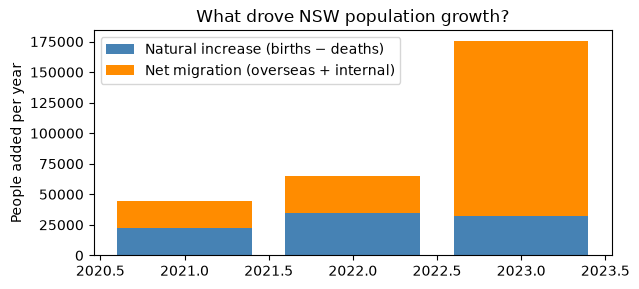

In [16]:
# Decomposition of NSW population growth: natural increase vs net migration
def get_row(measure_name):
    """Return a year-indexed Series for a single measure."""
    s = df.loc[df['measure'] == measure_name, year_cols].iloc[0]
    s.index = s.index.astype(int)
    return s.dropna()

births           = get_row('Births (no.)')
deaths           = get_row('Deaths (no.)')
net_overseas     = get_row('Net overseas migration (no.)')
net_internal     = get_row('Net internal migration (no.)')

years_keep = sorted(set(births.index) & set(deaths.index)
                    & set(net_overseas.index) & set(net_internal.index))

decomp = pd.DataFrame({
    'Births'             : births.loc[years_keep],
    'Deaths'             : deaths.loc[years_keep],
    'Natural increase'   : births.loc[years_keep] - deaths.loc[years_keep],
    'Net overseas mig.'  : net_overseas.loc[years_keep],
    'Net internal mig.'  : net_internal.loc[years_keep],
})
decomp['Total mig.']      = decomp['Net overseas mig.'] + decomp['Net internal mig.']
decomp['Total growth']    = decomp['Natural increase']  + decomp['Total mig.']
decomp['% from natural']  = (decomp['Natural increase'] / decomp['Total growth'] * 100).round(1)
decomp['% from migration']= (decomp['Total mig.']       / decomp['Total growth'] * 100).round(1)

print('NSW population-growth decomposition:')
print(decomp.round(0).to_string())

# Stacked bar — natural vs migration contribution
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(decomp.index, decomp['Natural increase'],
       label='Natural increase (births − deaths)', color='steelblue')
ax.bar(decomp.index, decomp['Total mig.'],
       bottom=decomp['Natural increase'],
       label='Net migration (overseas + internal)', color='darkorange')
ax.axhline(0, color='black', lw=0.6)
ax.set_title('What drove NSW population growth?')
ax.set_ylabel('People added per year'); ax.legend()
plt.savefig('natural_increase.png')
plt.tight_layout(); plt.show()



--> Clearly see, Natural increase stays positive but is shrinking (deaths rising, births falling). Net internal migration is negative every year — NSW is losing residents to other states (people moving to QLD/VIC). The recovery story comes from overseas migration snapping back from −5,940 in 2021 to +177,100 in 2023.
--> Headline finding for the report: in 2023, ~83% of NSW's population growth came from overseas migration — without it, NSW would barely be growing.

NSW age dependency ratios (per 100 working-age people):
      Youth dep. ratio  Old-age dep. ratio  Total dep. ratio
2019             28.46               25.08             53.54
2020             28.46               25.86             54.32
2021             28.67               26.75             55.42
2022             28.49               27.15             55.64
2023             27.72               27.09             54.81
2024             27.12               27.32             54.44

Change 2019 → 2024:
  Youth dep.   : -1.34 pts
  Old-age dep. : +2.24 pts
  Total        : +0.90 pts


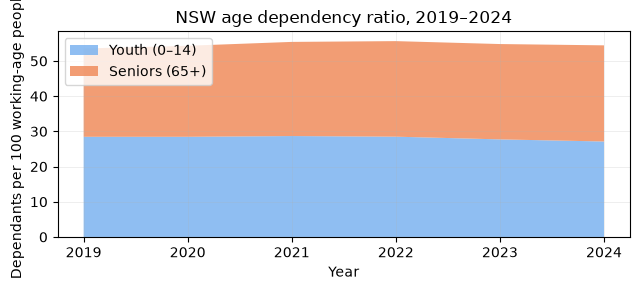

In [12]:
# Age dependency ratio? (Who is supporting who?)

import re

def sum_age_brackets(brackets):
    """Sum male+female ERP rows for the given list of 5-year bracket labels."""
    pattern = '|'.join([re.escape(b) for b in brackets])
    # `( years)?` makes the word optional so it matches both
    # "Males - 0-4 years (no.)" and "Males - 85 and over (no.)"
    regex = rf'^(Males|Females) - ({pattern})( years)? \(no\.\)$'
    mask = (df['measure'].str.match(regex, na=False)
            & df['category'].str.startswith('Estimated resident population'))
    s = df.loc[mask, year_cols].sum(axis=0)
    s.index = s.index.astype(int)
    return s.replace(0, np.nan).dropna()

# Build the three age-group totals
youth      = sum_age_brackets(['0-4', '5-9', '10-14'])                     # 0–14
seniors    = sum_age_brackets(['65-69','70-74','75-79','80-84','85 and over'])  # 65+

# Working-age comes straight from the ERP row (filtered to the main NSW category)
mask_wa = (df['measure'] == 'Working age population (aged 15-64 years) (no.)') & \
          df['category'].str.startswith('Estimated resident population - year ended')
working_age = df.loc[mask_wa, year_cols].iloc[0].dropna()
working_age.index = working_age.index.astype(int)

# Build the dependency-ratio table
years_keep = sorted(set(youth.index) & set(seniors.index) & set(working_age.index))
dep = pd.DataFrame({
    'Youth (0–14)' : youth.loc[years_keep],
    'Seniors (65+)': seniors.loc[years_keep],
    'Working age (15–64)': working_age.loc[years_keep],
})
dep['Youth dep. ratio']    = (dep['Youth (0–14)']  / dep['Working age (15–64)'] * 100).round(2)
dep['Old-age dep. ratio']  = (dep['Seniors (65+)'] / dep['Working age (15–64)'] * 100).round(2)
dep['Total dep. ratio']    = dep['Youth dep. ratio'] + dep['Old-age dep. ratio']

print('NSW age dependency ratios (per 100 working-age people):')
print(dep[['Youth dep. ratio','Old-age dep. ratio','Total dep. ratio']].to_string())

print(f"\nChange 2019 → 2024:")
print(f"  Youth dep.   : {dep['Youth dep. ratio'].iloc[-1] - dep['Youth dep. ratio'].iloc[0]:+.2f} pts")
print(f"  Old-age dep. : {dep['Old-age dep. ratio'].iloc[-1] - dep['Old-age dep. ratio'].iloc[0]:+.2f} pts")
print(f"  Total        : {dep['Total dep. ratio'].iloc[-1] - dep['Total dep. ratio'].iloc[0]:+.2f} pts")

# Stacked area chart — youth vs old-age burden over time
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.stackplot(dep.index,
             dep['Youth dep. ratio'], dep['Old-age dep. ratio'],
             labels=['Youth (0–14)', 'Seniors (65+)'],
             colors=['#7BB3F0', '#F08C5C'], alpha=0.85)
ax.set_title('NSW age dependency ratio, 2019–2024')
ax.set_ylabel('Dependants per 100 working-age people')
ax.set_xlabel('Year'); ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.savefig('age_dependency.png')
plt.tight_layout(); plt.show()


 - Youth dependency is shrinking — 28.5 → 27.1 (fewer kids per worker, mirroring the falling birth rate from stat #1).
Old-age dependency is rising every year — 25.1 → 27.3 (NSW is ageing).
 - Total ratio peaked in 2022 at 55.6, then fell in 2023–24 — but not because NSW got "younger". It fell because the post-COVID overseas migration wave (most arrivals are working-age 20–35) inflated the denominator faster than the seniors numerator grew.
-> Takeaway: Without the migration wave, NSW's dependency ratio would still be climbing.

NSW migration components (people):
      Overseas arrivals  Overseas departures  Net overseas mig.  Net internal mig.  Net total mig.
2021            72759.0              78699.0            -5940.0           -16822.0        -22762.0
2022           152865.0              83753.0            69112.0           -39335.0         29777.0
2023           250037.0              72937.0           177100.0           -34158.0        142942.0
2024           217211.0              79781.0           137430.0           -30865.0        106565.0

Cumulative 2021–2024:
  Net overseas migration :   +377,702  (+147.2% of total)
  Net internal migration :   -121,180
  Combined               :   +256,522


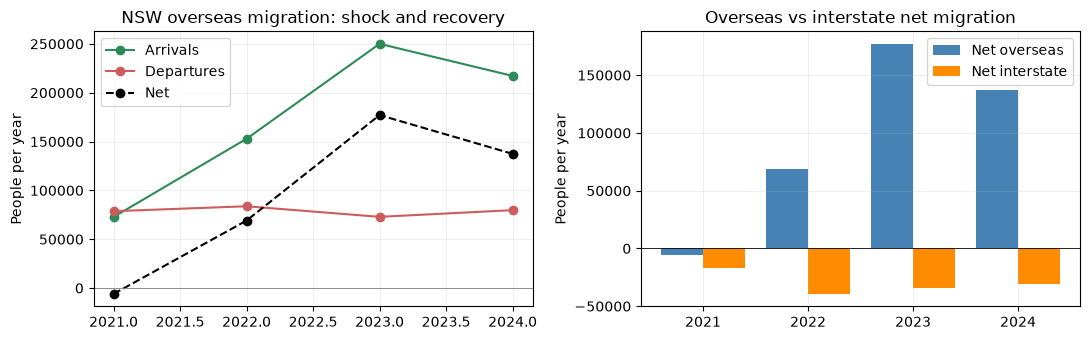

In [13]:
#NSW migration — the COVID shock and the post-COVID surge

def get_row(measure_name, category_substr=None):
    mask = df['measure'] == measure_name
    if category_substr is not None:
        mask &= df['category'].str.contains(category_substr, na=False)
    s = df.loc[mask, year_cols].iloc[0]
    s.index = s.index.astype(int)
    return s.dropna()

oa = get_row('Overseas arrivals (no.)')
od = get_row('Overseas departures (no.)')
no = get_row('Net overseas migration (no.)')
ni = get_row('Net internal migration (no.)')

mig = pd.DataFrame({
    'Overseas arrivals'   : oa,
    'Overseas departures' : od,
    'Net overseas mig.'   : no,
    'Net internal mig.'   : ni,
})
mig['Net total mig.'] = mig['Net overseas mig.'] + mig['Net internal mig.']

print('NSW migration components (people):')
print(mig.round(0).to_string())

# Cumulative net overseas migration over the period — total people gained from abroad
total_net_overseas = mig['Net overseas mig.'].sum()
total_net_internal = mig['Net internal mig.'].sum()
print(f"\nCumulative 2021–2024:")
print(f"  Net overseas migration : {total_net_overseas:>+10,.0f}  ({total_net_overseas/mig['Net total mig.'].sum()*100:+.1f}% of total)")
print(f"  Net internal migration : {total_net_internal:>+10,.0f}")
print(f"  Combined               : {mig['Net total mig.'].sum():>+10,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Panel 1 — overseas arrivals vs departures vs net
axes[0].plot(mig.index, mig['Overseas arrivals'],   marker='o', label='Arrivals',   color='seagreen')
axes[0].plot(mig.index, mig['Overseas departures'], marker='o', label='Departures', color='indianred')
axes[0].plot(mig.index, mig['Net overseas mig.'],   marker='o', label='Net',        color='black', linestyle='--')
axes[0].axhline(0, color='grey', lw=0.6)
axes[0].set_title('NSW overseas migration: shock and recovery')
axes[0].set_ylabel('People per year'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Panel 2 — net overseas vs net internal (interstate)
x = mig.index.astype(str)
w = 0.4
axes[1].bar([i - w/2 for i in range(len(x))], mig['Net overseas mig.'], width=w,
            label='Net overseas', color='steelblue')
axes[1].bar([i + w/2 for i in range(len(x))], mig['Net internal mig.'], width=w,
            label='Net interstate', color='darkorange')
axes[1].axhline(0, color='black', lw=0.6)
axes[1].set_xticks(range(len(x))); axes[1].set_xticklabels(x)
axes[1].set_title('Overseas vs interstate net migration')
axes[1].set_ylabel('People per year'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.savefig('overseas.png')
plt.tight_layout(); plt.show()


- 2021 was historically unprecedented. With international borders closed, NSW had negative net overseas migration (more people left the country from NSW than arrived) — the first such year in modern history.
- 2022–2023 was the biggest migration wave NSW has ever seen. Net overseas migration hit ~+177,000 in 2023 — that's the entire population of a regional city like Wollongong arriving in a single year.
- NSW continues to leak people interstate. Every year, around 30,000 more residents leave NSW for other states than arrive. Cost-of-living and housing pressures are the usual explanations.
- The combined picture: in 2021, NSW lost ~23,000 people to migration overall. In 2023, it gained ~143,000. Migration is by far the most volatile component of population change.

NSW Aboriginal & Torres Strait Islander population, 2011 → 2021:
      ATSI Census count  ATSI share of NSW (%)  ATSI ERP estimate  ATSI median age
2011             172620                    2.5             208476             21.4
2016             216171                    2.9             265685             22.6
2021             278043                    3.4             339710             23.4

Growth 2011 → 2021:
  ATSI population (Census basis): +61.1%
  ATSI population (ERP basis)   : +62.9%
  NSW total population (Census) : +18.4%
  → ATSI grew ~3.3× faster than NSW overall.

Median age 2021: ATSI = 23.4 yrs   |   NSW total = 38.6 yrs
  → NSW's ATSI population is 15.2 years younger on average.


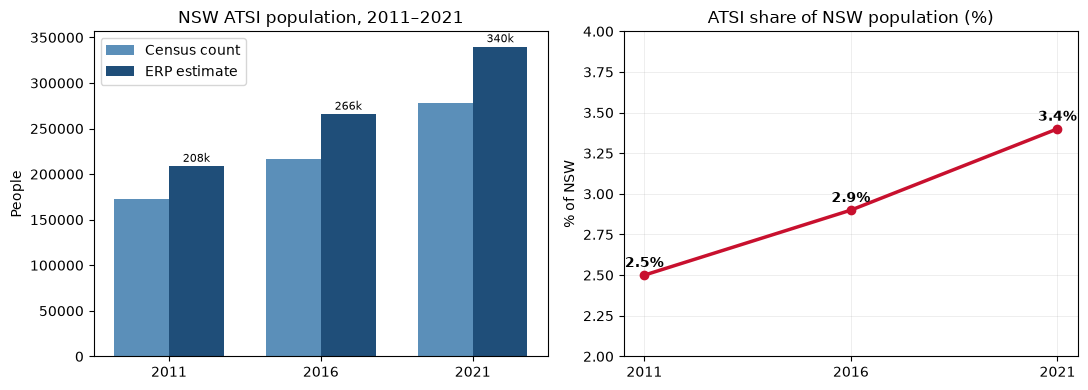

In [14]:
#Aboriginal & Torres Strait Island population growth

# (a) Census-based ATSI counts and share of NSW
atsi_cat = 'Aboriginal and Torres Strait Islander Peoples - Census'
atsi_no  = df.loc[(df['category']==atsi_cat) &
                  (df['measure']=='Aboriginal and Torres Strait Islander Peoples (no.)'),
                  ['2011','2016','2021']].iloc[0].astype(float)
atsi_pct = df.loc[(df['category']==atsi_cat) &
                  (df['measure']=='Aboriginal and Torres Strait Islander Peoples (%)'),
                  ['2011','2016','2021']].iloc[0].astype(float)

# (b) ERP-based ATSI counts
erp_cat = 'Estimated resident Aboriginal and Torres Strait Islander population - at 30 June'
atsi_erp = df.loc[(df['category']==erp_cat) &
                  (df['measure']=='Estimated resident Aboriginal and Torres Strait Islander population (no.)'),
                  ['2011','2016','2021']].iloc[0].astype(float)

# Median age
atsi_median_age = df.loc[(df['category']==erp_cat) &
                         (df['measure']=='Median age - persons (years)'),
                         ['2011','2016','2021']].iloc[0].astype(float)

# Build the comparison table
table = pd.DataFrame({
    'ATSI Census count'  : atsi_no.astype(int),
    'ATSI share of NSW (%)': atsi_pct,
    'ATSI ERP estimate'  : atsi_erp.astype(int),
    'ATSI median age'    : atsi_median_age,
})
print('NSW Aboriginal & Torres Strait Islander population, 2011 → 2021:')
print(table.to_string())

# Headline growth rates
g_census = (atsi_no.iloc[-1] / atsi_no.iloc[0] - 1) * 100
g_erp    = (atsi_erp.iloc[-1] / atsi_erp.iloc[0] - 1) * 100
# NSW total Census growth (back-calculated from the % share)
nsw_total_2011 = atsi_no.iloc[0] / (atsi_pct.iloc[0] / 100)
nsw_total_2021 = atsi_no.iloc[-1] / (atsi_pct.iloc[-1] / 100)
g_total = (nsw_total_2021 / nsw_total_2011 - 1) * 100

print(f'\nGrowth 2011 → 2021:')
print(f'  ATSI population (Census basis): {g_census:+.1f}%')
print(f'  ATSI population (ERP basis)   : {g_erp:+.1f}%')
print(f'  NSW total population (Census) : {g_total:+.1f}%')
print(f'  → ATSI grew ~{g_census/g_total:.1f}× faster than NSW overall.')

# Median-age comparison snapshot
nsw_median_2021 = df.loc[df['measure']=='Median age - persons (years)', '2021'].dropna().iloc[0]
print(f'\nMedian age 2021: ATSI = {atsi_median_age.iloc[-1]:.1f} yrs   |   NSW total = {nsw_median_2021:.1f} yrs')
print(f'  → NSW\'s ATSI population is {nsw_median_2021 - atsi_median_age.iloc[-1]:.1f} years younger on average.')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

years = ['2011', '2016', '2021']
axes[0].bar([i-0.18 for i in range(3)], atsi_no.values,  width=0.36,
            label='Census count', color='#5B8FB9')
axes[0].bar([i+0.18 for i in range(3)], atsi_erp.values, width=0.36,
            label='ERP estimate', color='#1F4E79')
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(years)
axes[0].set_title('NSW ATSI population, 2011–2021')
axes[0].set_ylabel('People'); axes[0].legend()
for i, v in enumerate(atsi_erp.values):
    axes[0].text(i+0.18, v+5000, f'{v/1000:,.0f}k', ha='center', fontsize=8)

axes[1].plot(years, atsi_pct.values, marker='o', color='#C8102E', linewidth=2.5)
axes[1].set_ylim(2.0, 4.0)
axes[1].set_title("ATSI share of NSW population (%)")
axes[1].set_ylabel('% of NSW'); axes[1].grid(alpha=0.3)
for i, v in enumerate(atsi_pct.values):
    axes[1].text(i, v+0.05, f'{v}%', ha='center', fontweight='bold')
plt.savefig('ATSI.png')
plt.tight_layout(); plt.show()


- NSW's Aboriginal & Torres Strait Islander population grew from ~173,000 to ~278,000 between the 2011 and 2021 Censuses — +61%, compared with +18% for NSW as a whole. That's roughly three times faster, and it lifted the ATSI share of NSW from 2.5% to 3.4%.
- Two forces are driving it. First, a much younger age structure: the ATSI median age is just 23.4 years, a full 15 years below NSW's overall median of 38.6. A younger population produces more births per capita, so it naturally grows faster. Second, an identification effect on the Census — each round, more Australians of ATSI descent choose to identify, reflecting reduced stigma and growing recognition. The ABS itself flags this as a major contributor to recent growth.
- The Census-based figure (+61%) and the ABS Estimated Resident Population figure (+63%) move together, which tells us the trend is real and not an artefact of one method.

NSW overseas-born population, region of birth (% of NSW):
                                      Region  2016  2021  Change (pts)
                   Southern and Central Asia   3.6   4.8           1.2
            North Africa and the Middle East   2.5   2.9           0.4
                             South-East Asia   4.0   4.4           0.4
                                    Americas   1.4   1.6           0.2
                          Sub-Saharan Africa   1.0   1.1           0.1
                             North-East Asia   4.8   4.8           0.0
Oceania and Antarctica (excluding Australia)   2.4   2.3          -0.1
                 Southern and Eastern Europe   2.9   2.7          -0.2
                           North-West Europe   5.0   4.7          -0.3

Total NSW residents born overseas:
  2016: 2,068,036  (27.6% of NSW)
  2021: 2,362,364  (29.3% of NSW)
  Net gain: +294,328 people

Biggest riser : Southern and Central Asia (+1.20 pts)
Biggest faller: North-West Europe (-0.30 pts)

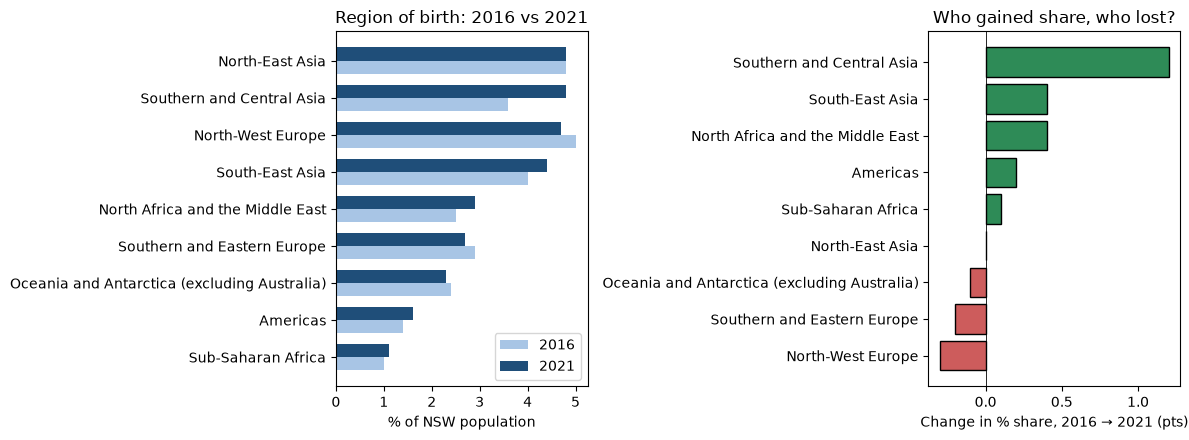

In [15]:
#NSW's changing immigrant origins

ob_cat = 'Overseas born population - Census'
sub = df[df['category'] == ob_cat][['measure','2016','2021']].copy()

# Keep only the regional rows (drop the two "Total born overseas" totals)
regions = sub[sub['measure'].str.startswith('Born in')].copy()
regions['Region'] = (regions['measure']
                     .str.replace(r'^Born in ', '', regex=True)
                     .str.replace(r' \(%\)$', '', regex=True))
regions = regions[['Region', '2016', '2021']].astype({'2016':float,'2021':float})
regions['Change (pts)'] = (regions['2021'] - regions['2016']).round(2)
regions = regions.sort_values('Change (pts)', ascending=False).reset_index(drop=True)

print('NSW overseas-born population, region of birth (% of NSW):')
print(regions.to_string(index=False))

# Headline numbers
total_no_2016 = df.loc[(df['category']==ob_cat) &
                       (df['measure']=='Total born overseas (no.)'), '2016'].iloc[0]
total_no_2021 = df.loc[(df['category']==ob_cat) &
                       (df['measure']=='Total born overseas (no.)'), '2021'].iloc[0]
total_pct_2016 = df.loc[(df['category']==ob_cat) &
                       (df['measure']=='Total born overseas (%)'), '2016'].iloc[0]
total_pct_2021 = df.loc[(df['category']==ob_cat) &
                       (df['measure']=='Total born overseas (%)'), '2021'].iloc[0]
print(f'\nTotal NSW residents born overseas:')
print(f'  2016: {total_no_2016:,.0f}  ({total_pct_2016}% of NSW)')
print(f'  2021: {total_no_2021:,.0f}  ({total_pct_2021}% of NSW)')
print(f'  Net gain: +{total_no_2021 - total_no_2016:,.0f} people')

biggest_riser = regions.iloc[0]
biggest_faller = regions.iloc[-1]
print(f'\nBiggest riser : {biggest_riser["Region"]} ({biggest_riser["Change (pts)"]:+.2f} pts)')
print(f'Biggest faller: {biggest_faller["Region"]} ({biggest_faller["Change (pts)"]:+.2f} pts)')

# --- Visual: side-by-side bars + change column ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1 — 2016 vs 2021 share, ordered by 2021
order = regions.sort_values('2021', ascending=True)
y = np.arange(len(order))
axes[0].barh(y - 0.18, order['2016'], height=0.36, label='2016', color='#A8C5E5')
axes[0].barh(y + 0.18, order['2021'], height=0.36, label='2021', color='#1F4E79')
axes[0].set_yticks(y); axes[0].set_yticklabels(order['Region'])
axes[0].set_xlabel('% of NSW population'); axes[0].legend()
axes[0].set_title('Region of birth: 2016 vs 2021')

# Panel 2 — change in pts, sorted high→low
ch = regions.sort_values('Change (pts)', ascending=True)
colors = ['seagreen' if v > 0 else 'indianred' for v in ch['Change (pts)']]
axes[1].barh(ch['Region'], ch['Change (pts)'], color=colors, edgecolor='black')
axes[1].axvline(0, color='black', lw=0.6)
axes[1].set_xlabel('Change in % share, 2016 → 2021 (pts)')
axes[1].set_title('Who gained share, who lost?')
plt.savefig('birth.png')
plt.tight_layout(); plt.show()


- Between the 2016 and 2021 Censuses, NSW gained almost 300,000 more overseas-born residents, lifting the share from 27.6% to 29.3% — nearly 3 in every 10 people in NSW.
- Southern and Central Asia (India, Sri Lanka, Pakistan, Nepal) was by far the biggest gainer: 3.6% → 4.8% of NSW (+1.2 pts), three times larger than any other region's movement.
- South-East Asia and the Middle East / North Africa each gained +0.4 pts.
- Both European regions lost share: North-West Europe (mostly UK/Ireland) 5.0% → 4.7%, and Southern/Eastern Europe 2.9% → 2.7%.
- North-East Asia (China, Japan, Korea) held steady at 4.8% — still the second-largest single source, but no longer the fastest-growing.
- Pattern: every region that gained share is non-European; almost the entire growth in NSW's overseas-born population is now driven by Asian and Middle-Eastern migration.
- Pairs cleanly with stat #3 (the migration surge): not just more migration, but a fundamentally different mix — old sources (UK, Europe) shrinking, new sources South Asian.